In [84]:
import pandas as pd
pd.set_option('max_colwidth', 100)
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import confusion_matrix
import itertools
import scipy.stats as st
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
#import seaborn as sns
#from matplotlib import pyplot as plt
#%matplotlib inline
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 500)
import rpy2
#import pingouin as pg
from itertools import combinations
import openpyxl
from contextlib import redirect_stdout
import random
import math
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency, fisher_exact

# Paths to data

In [34]:
# paths where to load files from
path_to_item_lookup = '../../data/ValSample/Internalizing-Somatoform Items_DW.xlsx'
path_to_cogmood_questions = '../../data/CFA/cogmood_questions.csv'
path_to_valsample = '../../data/ValSample/inters23.xlsx'
path_to_codesheet = '../../dylan_github/yougov_codesheet_alignment.tsv'
path_to_genpop = '../../data/NIMH0007_genpop_num_OUTPUT.csv'
path_to_enriched = '../../data/NIMH0007_mental_health_num_OUTPUT.csv'

# paths where to save preprocessed data files
path_save_val = '../../data/finaldata/dat_val.csv'
path_save_dat_gp_grid1st_norecontact = '../../data/finaldata/dat_gp_grid1st_norecontact.csv'
path_save_dat_en_grid1st_norecontact = '../../data/finaldata/dat_en_grid1st_norecontact.csv'
path_save_dat_gp_grid1st_full = '../../data/finaldata/dat_gp_grid1st_full.csv'
path_save_dat_en_grid1st_full = '../../data/finaldata/dat_en_grid1st_full.csv'
path_save_dat_gp_gridall_full = '../../data/finaldata/dat_gp_gridall_full.csv'
path_save_dat_en_gridall_full = '../../data/finaldata/dat_en_gridall_full.csv'
#path_save_dat_gp_gridall_recontact = '../../data/finaldata/dat_gp_gridall_recontact.csv'
#path_save_dat_en_gridall_recontact = '../../data/finaldata/dat_en_gridall_recontact.csv'

# 1 - Data load and process

## 1.1 - Functions

In [70]:
def make_hitop_list(data):
    # only hitop cols
    hitop_cols = []
    for c in data.columns:
        if 'hitop' in c and 'today' not in c:
            hitop_cols.append(c)   
    return(hitop_cols)

def make_recontact_list(data):
    list_recontact = []
    for c in data.columns:
        if 'recontact' in c:
            list_recontact.append(c)
    return(list_recontact)

def do_checks(dat, remove_checks):
    assert remove_checks in ['no', 'yes', 'grid', 'gridinitialvisitonly']
    dat['passed_checks'] = True
    dat['passed_grid'] = True
    dat['passed_grid_initialonly'] = True
    dat['passed_list'] = True
    dat.loc[dat.check_moderately != 3, 'passed_checks'] = False
    dat.loc[dat.check_notatall != 1, 'passed_checks'] = False
    dat.loc[dat.check_moderately != 3, 'passed_grid'] = False
    dat.loc[dat.check_notatall != 1, 'passed_grid'] = False
    dat.loc[dat.todaycheck_1 != 1, 'passed_checks'] = False
    dat.loc[dat.todaycheck_2 != 1, 'passed_checks'] = False
    dat.loc[dat.todaycheck_1 != 1, 'passed_list'] = False
    dat.loc[dat.todaycheck_2 != 1, 'passed_list'] = False
    # deal with attention checks - recontact
    dat['passed_checks_recontact'] = True
    dat['passed_grid_recontact'] = True
    dat['passed_list_recontact'] = True
    dat.loc[dat.check_moderately_recontact != 3, 'passed_checks_recontact'] = False
    dat.loc[dat.check_notatall_recontact != 1, 'passed_checks_recontact'] = False
    dat.loc[dat.check_moderately_recontact != 3, 'passed_grid_recontact'] = False
    dat.loc[dat.check_notatall_recontact != 1, 'passed_grid_recontact'] = False
    dat.loc[dat.todaycheck_1_recontact != 1, 'passed_checks_recontact'] = False
    dat.loc[dat.todaycheck_2_recontact != 1, 'passed_checks_recontact'] = False
    dat.loc[dat.todaycheck_1_recontact != 1, 'passed_list_recontact'] = False
    dat.loc[dat.todaycheck_2_recontact != 1, 'passed_list_recontact'] = False
    
    #print('checks_initial:')
    #print(1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean())
    print('\non intial visit')
    print('\nThis is how many ppl passed attention checks:')
    print('Calculated as 1 - dat.loc[:, [\'passed_checks\', \'passed_grid\', \'passed_list\']].mean()')
    print(1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean())
    how_many_passed_checks = dat['passed_checks'].value_counts()[True]
    how_many_failed_checks = dat['passed_checks'].value_counts()[False]
    how_many_passed_grid = dat['passed_grid'].value_counts()[True]
    how_many_failed_grid = dat['passed_grid'].value_counts()[False]
    how_many_passed_list = dat['passed_list'].value_counts()[True]
    how_many_failed_list = dat['passed_list'].value_counts()[False]
    how_many_overall = dat.shape[0]
    print('\nPassed checks: %d out of %d' % (how_many_passed_checks, how_many_overall))
    print('Failed checks: %d out of %d' % (how_many_failed_checks, how_many_overall))
    print('Passed grid: %d out of %d' % (how_many_passed_grid, how_many_overall))
    print('Failed grid: %d out of %d' % (how_many_failed_grid, how_many_overall))
    print('Passed list: %d out of %d' % (how_many_passed_list, how_many_overall))
    print('Failed list: %d out of %d' % (how_many_failed_list, how_many_overall))
    
    print('\non recontact visit:')
    #print(1 - dat.loc[:, ['passed_checks_recontact', 'passed_grid_recontact', 'passed_list_recontact']].mean()) 
    how_many_passed_checks_recontact = dat['passed_checks_recontact'].value_counts()[True]
    how_many_failed_checks_recontact = dat['passed_checks_recontact'].value_counts()[False]
    how_many_passed_grid_recontact = dat['passed_grid_recontact'].value_counts()[True]
    how_many_failed_grid_recontact = dat['passed_grid_recontact'].value_counts()[False]
    print('\nPassed checks: %d out of %d' % (how_many_passed_checks_recontact, how_many_overall))
    print('Failed checks: %d out of %d' % (how_many_failed_checks_recontact, how_many_overall))
    print('Passed grid: %d out of %d' % (how_many_passed_grid_recontact, how_many_overall))
    print('Failed grid: %d out of %d' % (how_many_failed_grid_recontact, how_many_overall))
    
    if remove_checks == 'yes':
        print('removing checks')
        dat = dat.loc[dat['passed_checks'] == True]
        dat = dat.loc[dat['passed_checks_recontact'] == True]
    elif remove_checks == 'grid':
        print('removing checks')
        dat = dat.loc[dat['passed_grid'] == True]
        dat = dat.loc[dat['passed_grid_recontact'] == True]
    elif remove_checks == 'gridinitialvisitonly':
        print('removing checks')
        dat = dat.loc[dat['passed_grid'] == True]
    print(dat.shape)
    print('done removing checks')        
    return(dat)

def load_item_lookup():
    # this is a table that aligns scale items with their corresponding questions
    htqs = pd.read_excel(path_to_item_lookup, skiprows=2,
                                names=['id', 'scale', 'item', '_0', '_1', '_2', '_3']).drop(['_0', '_1', '_2', '_3'], axis=1)
    # cmqs is a dataframe with items and responses
    # htcm is the same dataframe, but only displaying HiTOP items
    cmqs = pd.read_csv(path_to_cogmood_questions)
    cmqs = cmqs.rename({'Unnamed: 0': 'id'}, axis=1)
    htcm = cmqs.query("measure == 'HiTOP'")
    # this is a lookup table for subscales, items (sentence questions), and hitop ids
    item_lookup = htcm.loc[:, ['id','subscale', 'item']].merge(htqs.loc[:, ['id','item']], how='inner', on='item', suffixes=['_cm', '_ht'])
    item_lookup['htid'] = 'hitop'+ item_lookup.id_ht.astype(str)
    return(item_lookup)
    
def load_valsample():
    # VALIDATION SAMPLE - main dataframe with responses
    dat_validation = pd.read_excel(path_to_valsample)
    '''resp_cols = responses.columns[responses.columns.isin(item_lookup.htid)]
    # scale scores
    scale_scores = []
    for ss, df in item_lookup.groupby('subscale'):
        tmp = responses.loc[:, df.htid].sum(1)
        tmp.name = ss.replace(" ", "_").replace("/", "_").replace("-", "_")
        scale_scores.append(tmp)
    scale_scores = pd.concat(scale_scores, axis=1)
    scale_names = list(scale_scores.columns.values)'''
    #do_checks(dat_validation)    
    # this is the validation data to be used
    hitop_cols_list = make_hitop_list(dat_validation)
    data_validation = dat_validation[hitop_cols_list]
    data_validation = data_validation.assign(whichdata=['validation']*data_validation.shape[0])
    return(dat_validation, data_validation)

def do_codesheet():
    #loads the codesheet file
    # wherever the emane column exists, creates a dict variablename:ename
    code_book = pd.read_csv(path_to_codesheet, sep='\t')
    ename_lut = {vn:en for vn, en in code_book.loc[code_book.ename.notnull(), ['var_name', 'ename']].values}
    for vn, en in code_book.loc[code_book.ename.notnull(), ['var_name', 'ename']].values:
        ename_lut[vn+'_recontact'] = en+'_recontact'
    tmp = code_book.query('ename.notnull()')
    scale_lut = {}
    for ss, df in tmp.loc[tmp.ename.str.contains('hitop') & ~tmp.ename.str.contains('today')].groupby('subscale'):
        scale_name = ss.replace(" ", "_").replace("/", "_").replace("-", "_")
        items = df.ename.values
        scale_lut[scale_name] = items    
     #   scale_name_initial = scale_name+'_initial'
     #   scale_lut[scale_name_initial] = items 
        scale_name_recontact = scale_name+'_recontact'
        items_recontact = []
        for item in items:
            items_recontact.append(item+'_recontact')
        scale_lut[scale_name_recontact] = np.array(items_recontact, dtype=object)
    # rename checks
    ename_lut['FNM_Q8_5'] ='check_moderately'
    ename_lut['FNM_Q22_3'] ='check_notatall'
    ename_lut['FNM_Q42_m_10'] ='todaycheck_1'
    ename_lut['FNM_44_m_28'] ='todaycheck_2'
    ename_lut['FNM_Q8_5_recontact'] ='check_moderately_recontact'
    ename_lut['FNM_Q22_3_recontact'] ='check_notatall_recontact'
    ename_lut['FNM_Q42_m_10_recontact'] ='todaycheck_1_recontact'
    ename_lut['FNM_44_m_28_recontact'] ='todaycheck_2_recontact'
    return ename_lut, scale_lut

def clean_mood_diagnosis(dat):
    # clean mood diagnosis
    dat['mood_dx'] = ''
    dat['n_mood_dx'] = (dat.loc[:, ['FNM_Q25_1', 'FNM_Q25_2', 'FNM_Q25_3', 'FNM_Q25_4', 'FNM_Q25_5', 'FNM_Q25_6']]==1).sum(1)
    dat.loc[dat.FNM_Q25_955 == 1, 'mood_dx'] = 'other'
    dat.loc[dat.FNM_Q25_1 == 1, 'mood_dx'] = 'mdd'
    dat.loc[dat.FNM_Q25_2 == 1, 'mood_dx'] = 'persistent'
    dat.loc[dat.FNM_Q25_3 == 1, 'mood_dx'] = 'premenstrual'
    dat.loc[dat.FNM_Q25_4 == 1, 'mood_dx'] = 'bipolarI'
    dat.loc[dat.FNM_Q25_5 == 1, 'mood_dx'] = 'bipolarII'
    dat.loc[dat.FNM_Q25_6 == 1, 'mood_dx'] = 'cyclothymic'
    dat.loc[dat.n_mood_dx > 1, 'mood_dx'] = 'multiple'
    # clean other mood columns
    dat.loc[dat.mood_years == 999, 'mood_years'] = np.nan
    dat['mood_bothered']=False
    dat.loc[dat.mood_bothered_orig == 1, 'mood_bothered'] = True
    return(dat)

def clean_mood_diagnosis_recontact(dat):
    # clean mood diagnosis - recontact
    dat['mood_dx_recontact'] = ''
    dat['n_mood_dx_recontact'] = (dat.loc[:, ['FNM_Q25_1_recontact', 'FNM_Q25_2_recontact', 'FNM_Q25_3_recontact', 'FNM_Q25_4_recontact', 'FNM_Q25_5_recontact', 'FNM_Q25_6_recontact']]==1).sum(1)
    dat.loc[dat.FNM_Q25_955_recontact == 1, 'mood_dx_recontact'] = 'other'
    dat.loc[dat.FNM_Q25_1_recontact == 1, 'mood_dx_recontact'] = 'mdd'
    dat.loc[dat.FNM_Q25_2_recontact == 1, 'mood_dx_recontact'] = 'persistent'
    dat.loc[dat.FNM_Q25_3_recontact == 1, 'mood_dx_recontact'] = 'premenstrual'
    dat.loc[dat.FNM_Q25_4_recontact == 1, 'mood_dx_recontact'] = 'bipolarI'
    dat.loc[dat.FNM_Q25_5_recontact == 1, 'mood_dx_recontact'] = 'bipolarII'
    dat.loc[dat.FNM_Q25_6_recontact == 1, 'mood_dx_recontact'] = 'cyclothymic'
    dat.loc[dat.n_mood_dx_recontact > 1, 'mood_dx_recontact'] = 'multiple'
    # clean other mood columns - recontact
    # clean other mood columns
    dat.loc[dat.mood_years_recontact == 999, 'mood_years_recontact'] = np.nan
    dat['mood_bothered_recontact']=False
    dat.loc[dat.mood_bothered_recontact_orig == 1, 'mood_bothered_recontact'] = True
    return(dat)

def clean_anxiety_diagnosis(dat):
    # clean anxiety diagnosis
    dat['anxiety_dx'] = ''
    dat['n_anxiety_dx'] = (dat.loc[:, ['FNM_Q30_m_1',
                                       'FNM_Q30_m_2',
                                       'FNM_Q30_m_3', 
                                       'FNM_Q30_m_4', 
                                       'FNM_Q30_m_5',
                                       'FNM_Q30_m_6',
                                       'FNM_Q30_m_7',
                                       'FNM_Q30_m_8',]]==1).sum(1)
    dat.loc[dat.FNM_Q30_m_955 == 1, 'anxiety_dx'] = 'other'
    dat.loc[dat.FNM_Q30_m_1 == 1, 'anxiety_dx'] = 'gad'
    dat.loc[dat.FNM_Q30_m_2 == 1, 'anxiety_dx'] = 'separation'
    dat.loc[dat.FNM_Q30_m_3 == 1, 'anxiety_dx'] = 'agoraphobia'
    dat.loc[dat.FNM_Q30_m_4 == 1, 'anxiety_dx'] = 'phobia'
    dat.loc[dat.FNM_Q30_m_5 == 1, 'anxiety_dx'] = 'social'
    dat.loc[dat.FNM_Q30_m_6 == 1, 'anxiety_dx'] = 'panic_disorder'
    dat.loc[dat.FNM_Q30_m_7 == 1, 'anxiety_dx'] = 'panic_attack'
    dat.loc[dat.FNM_Q30_m_8 == 1, 'anxiety_dx'] = 'mutism'
    dat.loc[dat.n_anxiety_dx > 1, 'anxiety_dx'] = 'multiple'
    # clean other anxiety columns
    dat.loc[dat.anxiety_years == 999, 'anxiety_years'] = np.nan
    dat['anxiety_bothered']=False
    dat.loc[dat.anxiety_bothered_orig == 1, 'anxiety_bothered'] = True
    return(dat)

def clean_anxiety_diagnosis_recontact(dat):
    # clean anxiety diagnosis - recontact
    dat['anxiety_dx_recontact'] = ''
    dat['n_anxiety_dx_recontact'] = (dat.loc[:, ['FNM_Q30_m_1_recontact',
                                       'FNM_Q30_m_2_recontact',
                                       'FNM_Q30_m_3_recontact', 
                                       'FNM_Q30_m_4_recontact', 
                                       'FNM_Q30_m_5_recontact',
                                       'FNM_Q30_m_6_recontact',
                                       'FNM_Q30_m_7_recontact',
                                       'FNM_Q30_m_8_recontact',]]==1).sum(1)
    dat.loc[dat.FNM_Q30_m_955_recontact == 1, 'anxiety_dx_recontact'] = 'other'
    dat.loc[dat.FNM_Q30_m_1_recontact == 1, 'anxiety_dx_recontact'] = 'gad'
    dat.loc[dat.FNM_Q30_m_2_recontact == 1, 'anxiety_dx_recontact'] = 'separation'
    dat.loc[dat.FNM_Q30_m_3_recontact == 1, 'anxiety_dx_recontact'] = 'agoraphobia'
    dat.loc[dat.FNM_Q30_m_4_recontact == 1, 'anxiety_dx_recontact'] = 'phobia'
    dat.loc[dat.FNM_Q30_m_5_recontact == 1, 'anxiety_dx_recontact'] = 'social'
    dat.loc[dat.FNM_Q30_m_6_recontact == 1, 'anxiety_dx_recontact'] = 'panic_disorder'
    dat.loc[dat.FNM_Q30_m_7_recontact == 1, 'anxiety_dx_recontact'] = 'panic_attack'
    dat.loc[dat.FNM_Q30_m_8_recontact == 1, 'anxiety_dx_recontact'] = 'mutism'
    
    dat.loc[dat.n_anxiety_dx_recontact > 1, 'anxiety_dx_recontact'] = 'multiple'
    # clean other anxiety columns - recontact
    dat.loc[dat.anxiety_years_recontact == 999, 'anxiety_years_recontact'] = np.nan
    dat['anxiety_bothered_recontact']=False
    dat.loc[dat.anxiety_bothered_recontact_orig == 1, 'anxiety_bothered_recontact'] = True
    return(dat)

def clean_attnt_dx(dat):
    # clean attention diagnosis
    dat['attention_dx'] = ''
    dat['n_attention_dx'] = (dat.loc[:, ['FNM_Q35_m_1',
                                       'FNM_Q35_m_2',
                                      ]]==1).sum(1)
    dat.loc[dat.FNM_Q35_m_3 == 1, 'attention_dx'] = 'other'
    dat.loc[dat.FNM_Q35_m_1 == 1, 'attention_dx'] = 'adhd'
    dat.loc[dat.FNM_Q35_m_2 == 1, 'attention_dx'] = 'adhd'
    
    # clean other attention columns
    dat.loc[dat.attention_years == 999, 'attention_years'] = np.nan
    dat['attention_bothered']=False
    dat.loc[dat.attention_bothered_orig == 1, 'attention_bothered'] = True
    return(dat)

def clean_attnt_dx_recontact(dat):
    # clean attention diagnosis - recontact
    dat['attention_dx_recontact'] = ''
    dat['n_attention_dx_recontact'] = (dat.loc[:, ['FNM_Q35_m_1_recontact',
                                       'FNM_Q35_m_2_recontact',
                                      ]]==1).sum(1)
    dat.loc[dat.FNM_Q35_m_3_recontact == 1, 'attention_dx_recontact'] = 'other'
    dat.loc[dat.FNM_Q35_m_1_recontact == 1, 'attention_dx_recontact'] = 'adhd'
    dat.loc[dat.FNM_Q35_m_2_recontact == 1, 'attention_dx_recontact'] = 'adhd'
    
    # clean other attention columns - recontact
    dat.loc[dat.attention_years_recontact == 999, 'attention_years_recontact'] = np.nan
    dat['attention_bothered_recontact']=False
    dat.loc[dat.attention_bothered_recontact_orig == 1, 'attention_bothered_recontact'] = True
    return(dat)

def define_attnt_checks(dat):
    # deal with attention checks 
    dat['passed_checks'] = True
    dat['passed_grid'] = True
    dat['passed_list'] = True
    dat.loc[dat.check_moderately != 3, 'passed_checks'] = False
    dat.loc[dat.check_notatall != 1, 'passed_checks'] = False
    dat.loc[dat.check_moderately != 3, 'passed_grid'] = False
    dat.loc[dat.check_notatall != 1, 'passed_grid'] = False
    dat.loc[dat.todaycheck_1 != 1, 'passed_checks'] = False
    dat.loc[dat.todaycheck_2 != 1, 'passed_checks'] = False
    dat.loc[dat.todaycheck_1 != 1, 'passed_list'] = False
    dat.loc[dat.todaycheck_2 != 1, 'passed_list'] = False 
    # deal with attention checks - recontact
    dat['passed_checks_recontact'] = True
    dat['passed_grid_recontact'] = True
    dat['passed_list_recontact'] = True
    dat.loc[dat.check_moderately_recontact != 3, 'passed_checks_recontact'] = False
    dat.loc[dat.check_notatall_recontact != 1, 'passed_checks_recontact'] = False
    dat.loc[dat.check_moderately_recontact != 3, 'passed_grid_recontact'] = False
    dat.loc[dat.check_notatall_recontact != 1, 'passed_grid_recontact'] = False
    dat.loc[dat.todaycheck_1_recontact != 1, 'passed_checks_recontact'] = False
    dat.loc[dat.todaycheck_2_recontact != 1, 'passed_checks_recontact'] = False
    dat.loc[dat.todaycheck_1_recontact != 1, 'passed_list_recontact'] = False
    dat.loc[dat.todaycheck_2_recontact != 1, 'passed_list_recontact'] = False
    # how many passed checks?
    print('\nThis is how many ppl passed attention checks:')
    print('Calculated as 1 - dat.loc[:, [\'passed_checks\', \'passed_grid\', \'passed_list\']].mean()')
    print(1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean())
    print('Same for recontact:')
    print(1 - dat.loc[:, ['passed_checks_recontact', 'passed_grid_recontact', 'passed_list_recontact']].mean())
    return(dat)
    
def load_data(dataname, doing_checks, doing_remove_checks):
    print(doing_remove_checks)
    assert(dataname in ['genpop','enriched'])
    
    #codesheet file
    ename_lut, scale_lut = do_codesheet()
    
    # done working with the codesheet file, now opening the actual data
    if dataname == 'genpop':
        datapath = path_to_genpop
    elif dataname == 'enriched':
        datapath = path_to_enriched
    dat = pd.read_csv(datapath, dtype={'caseid':str}, engine='python')
    if dataname == 'genpop':
        # ONLY GENPOP drop the .0 that pandas appends for some reason - only for genpop
        dat['caseid'] = dat.caseid.str[:-2]
    
    #renaming columns
    dat = dat.rename(ename_lut, axis=1)
    dat = dat.rename(columns={
        'mood_bothered': 'mood_bothered_orig',
        'mood_bothered_recontact': 'mood_bothered_recontact_orig',
        'anxiety_bothered': 'anxiety_bothered_orig',
        'anxiety_bothered_recontact': 'anxiety_bothered_recontact_orig',
        'attention_bothered': 'attention_bothered_orig',
        'attention_bothered_recontact': 'attention_bothered_recontact_orig'}) 
    
    # clean diagnoses
    dat = clean_mood_diagnosis(dat)
    dat = clean_mood_diagnosis_recontact(dat)
    dat = clean_anxiety_diagnosis(dat)
    dat = clean_anxiety_diagnosis_recontact(dat)
    dat = clean_attnt_dx(dat)
    dat = clean_attnt_dx_recontact(dat)
    
    if doing_checks:
        dat = do_checks(dat = dat, remove_checks = doing_remove_checks) 

    '''
    minus_1_cols = []
    m1_stems = ['inattention', 'hyperactivity', 'impulsivity', 'sct', 'gad', 'phq', 'hitop',
           'inattention_recontact', 'hyperactivity_recontact', 'impulsivity_recontact', 'sct_recontact', 'gad_recontact', 'phq_recontact', 'hitop_recontact']
    for ms in m1_stems:
        #print(ms)
        if "recontact" not in ms:
            cols = list(dat.columns[dat.columns.str.contains(ms) & ~dat.columns.str.contains('today') & ~dat.columns.str.contains('sum') & ~dat.columns.str.contains('recontact')].values)
        else:
            cols = list(dat.columns[dat.columns.str.contains(ms[:-10]) & ~dat.columns.str.contains('today') & ~dat.columns.str.contains('sum') & dat.columns.str.contains('recontact')].values)
        #print(cols)
        minus_1_cols.extend(cols)

    #debug line
    print("\n\n ++++++++++++++ MINUS ONE COLUMNS ++++++++++++++ ")
    print(minus_1_cols)

    # why are we doing this
    # subtract 1 from responses
    dat.loc[:, minus_1_cols] -= 1
    '''
    m1_stems = ['inattention', 'hyperactivity', 'impulsivity', 'sct', 'gad', 'phq', 'hitop',
           'inattention_recontact', 'hyperactivity_recontact', 'impulsivity_recontact', 'sct_recontact', 'gad_recontact', 'phq_recontact', 'hitop_recontact']


    # summing up the values
    sum_cols = []
    for ms in m1_stems:
        if 'hitop' not in ms:
            if "recontact" not in ms:
                cols = list(dat.columns[dat.columns.str.contains(ms) & ~dat.columns.str.contains('today') & ~dat.columns.str.contains('sum') & ~dat.columns.str.contains('recontact')].values)
                dat[f'{ms}_sum'] = dat.loc[:, cols].sum(1)
                sum_cols.append(ms + '_sum')
            else:
                cols = list(dat.columns[dat.columns.str.contains(ms[:-10]) & ~dat.columns.str.contains('today') & ~dat.columns.str.contains('sum') & dat.columns.str.contains('recontact')].values)
                dat[f'{ms[:-10]}_sum_recontact'] = dat.loc[:, cols].sum(1)
                sum_cols.append(ms[:-10] + '_sum_recontact')    
    hitop_sums = []
    for scale_name, items in scale_lut.items():
        dat[scale_name] = dat.loc[:, items].sum(1) # adding a dat[scale_name] with a sum of all values ("items)"
        hitop_sums.append(scale_name)   

    sum = 0
    for scale_name, items in scale_lut.items():
        if "well_being" not in scale_name:
            sum += len(items)

    # !!!!!!!!!! double-check this
    dat['hitop_sum'] = dat.loc[:, hitop_sums[::2][:-1]].sum(1)  # [:-1] because we don't include the well-being scale
    dat['hitop_sum_recontact'] = dat.loc[:, hitop_sums[1::2][:-1]].sum(1)
    dat['baars_sum'] = dat.inattention_sum + dat.hyperactivity_sum + dat.impulsivity_sum
    dat['baars_sum_recontact'] = dat.inattention_sum_recontact + dat.hyperactivity_sum_recontact + dat.impulsivity_sum_recontact
    dat['moodanxiety_bothered'] = dat.mood_bothered | dat.anxiety_bothered
    dat['moodanxiety_bothered_recontact'] = dat.mood_bothered_recontact | dat.anxiety_bothered_recontact

    my_columns = []
    for item in ['hitop_sum', 'baars_sum', 'phq_sum', 'gad_sum', # all sums
                 'mood_bothered','anxiety_bothered', 'attention_bothered', 'moodanxiety_bothered', # bothered
                 'inattention_sum', 'hyperactivity_sum', 'impulsivity_sum', 'sct_sum']: # each subscale of baars
        my_columns.append(item)
        my_columns.append(item+'_recontact')
    my_columns.extend(hitop_sums) #each subscale of hitop

        # rename columns with phq and gad sums for cnsistency in naming
    dat = dat.rename(columns={"gad_recontact_sum": "gad_sum_recontact", "phq_recontact_sum": "phq_sum_recontact"})

    # rename baars subscales
    dat = dat.rename(columns={"inattention_sum": "baars_inattention_sum", 
                          "inattention_sum_recontact": "baars_inattention_sum_recontact",
                          "hyperactivity_sum": "baars_hyperactivity_sum", 
                          "hyperactivity_sum_recontact": "baars_hyperactivity_sum_recontact",
                          "impulsivity_sum": "baars_impulsivity_sum", 
                          "impulsivity_sum_recontact": "baars_impulsivity_sum_recontact",
                          "sct_sum": "baars_sct_sum",
                          "sct_sum_recontact": "baars_sct_sum_recontact"})

    # rename hitops subscales
    rename_dict = {}
    for hitop_item in hitop_sums:
        rename_dict[hitop_item] = 'hitop_' + hitop_item
    dat = dat.rename(columns=rename_dict)
    
    hitop_cols_list = make_hitop_list(dat)
    dat = dat.assign(whichdata=[dataname]*dat.shape[0])
    
    data = dat[hitop_cols_list]
    data = data.assign(whichdata=[dataname]*data.shape[0])
    recontact_cols_list = make_recontact_list(data)
    data_norecontact = data.drop(columns=recontact_cols_list)
    return dat, data, data_norecontact   

def prep_data_recontactanalysis(dataframe_withrecontact):
    df = dataframe_withrecontact
    df_helper = df.copy(deep=True)
    df_rows = df.shape[0]
    df = df.assign(whichvisit=['initialvisit']*df_rows)
    df_helper = df_helper.assign(whichvisit=['recontactvisit']*df_rows)
    # in df, drop all "recontact" columns
    # in df_helper, drop all initial visit columns, then rename the recontact columns
    cols_recontact = []
    cols_original = []
    for c in df.columns:
        if "recontact" in c:
            cols_recontact.append(c)
            cols_original.append(c[:-10])  
    df = df.drop(columns=cols_recontact)
    df_helper = df_helper.drop(columns=cols_original)
    cols_dict = {}
    for cname in cols_recontact:
        cols_dict[cname] = cname[:-10]
    # rename cols in df_helper
    df_helper.rename(columns=cols_dict, inplace=True)    
    mydata_withrecontact = pd.concat([df, df_helper])
    return(mydata_withrecontact)

## 1.2 Validation data - Load, process and save

In [71]:
# Load item_lookup
item_lookup = load_item_lookup()

# Load validation data 
(data_val_full, data_val) = load_valsample()

data_val.to_csv(path_save_val)

/Users/zeleninam2/miniconda3/envs/env_semtools_fix/lib/python3.11/site-packages/openpyxl/worksheet/_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


In [72]:
# check how val is coded
for c in data_val.columns:
    print(f'\n\n{c}\n')
    print(f'min: {data_val[c].min()}, max: {data_val[c].max()}')



hitop39

min: 1, max: 4


hitop77

min: 1, max: 4


hitop84

min: 1, max: 4


hitop92

min: 1, max: 4


hitop93

min: 1, max: 4


hitop123

min: 1, max: 4


hitop157

min: 1, max: 4


hitop182

min: 1, max: 4


hitop230

min: 1, max: 4


hitop246

min: 1, max: 4


hitop20

min: 1, max: 4


hitop34

min: 1, max: 4


hitop89

min: 1, max: 4


hitop203

min: 1, max: 4


hitop240

min: 1, max: 4


hitop248

min: 1, max: 4


hitop265

min: 1, max: 4


hitop120

min: 1, max: 4


hitop141

min: 1, max: 4


hitop243

min: 1, max: 4


hitop275

min: 1, max: 4


hitop109

min: 1, max: 4


hitop280

min: 1, max: 4


hitop283

min: 1, max: 4


hitop67

min: 1, max: 4


hitop142

min: 1, max: 4


hitop159

min: 1, max: 4


hitop189

min: 1, max: 4


hitop5

min: 1, max: 4


hitop66

min: 1, max: 4


hitop99

min: 1, max: 4


hitop181

min: 1, max: 4


hitop231

min: 1, max: 4


hitop21

min: 1, max: 4


hitop90

min: 1, max: 4


hitop95

min: 1, max: 4


hitop160

min: 1, max: 4


hitop254

min: 

## 1.3 Data for CFA and conv/div - remove grid 1st visit only - Load, process and save

In [38]:
# --- FOR CFA and conv/div - remove grid checks on 1st visit only ---

# Load genpop data
print('\n Process GP data')
data_genpop_full_grid1st, data_genpop_grid1st, data_genpop_norecontact_grid1st = load_data('genpop', doing_checks = True, doing_remove_checks='gridinitialvisitonly')

# Load enriched data
print('\n Process EN data')
data_enriched_full_grid1st, data_enriched_grid1st, data_enriched_norecontact_grid1st = load_data('enriched', doing_checks = True, doing_remove_checks='gridinitialvisitonly')

# save for cfa
data_genpop_norecontact_grid1st.to_csv(path_save_dat_gp_grid1st_norecontact)
data_enriched_norecontact_grid1st.to_csv(path_save_dat_en_grid1st_norecontact)

#save for conv/div
data_genpop_full_grid1st.to_csv(path_save_dat_gp_grid1st_full)
data_enriched_full_grid1st.to_csv(path_save_dat_en_grid1st_full)


 Process GP data
gridinitialvisitonly

on intial visit

This is how many ppl passed attention checks:
Calculated as 1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean()
passed_checks    0.462
passed_grid      0.006
passed_list      0.458
dtype: float64

Passed checks: 269 out of 500
Failed checks: 231 out of 500
Passed grid: 497 out of 500
Failed grid: 3 out of 500
Passed list: 271 out of 500
Failed list: 229 out of 500

on recontact visit:

Passed checks: 226 out of 500
Failed checks: 274 out of 500
Passed grid: 400 out of 500
Failed grid: 100 out of 500
removing checks
(497, 753)
done removing checks

 Process EN data
gridinitialvisitonly

on intial visit

This is how many ppl passed attention checks:
Calculated as 1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean()
passed_checks    0.293548
passed_grid      0.016129
passed_list      0.290323
dtype: float64

Passed checks: 219 out of 310
Failed checks: 91 out of 310
Passed grid: 305 out of 310
Fa

In [39]:
# chech how baars, gad, phq, hitop are coded
for c in ['gad_1', 'gad_2', 'phq_1', 'phq_2', \
          'inattention_1', 'inattention_2', 'hyperactivity_1', 'hyperactivity_2', 'impulsivity_1', 'impulsivity_2', 'sct_1', 'sct_2',
          'hitop157', 'hitop81']:
    print(f'\n\n{c}\n')
    print(f'DP: min: {data_genpop_full_grid1st[c].min()}, max: {data_genpop_full_grid1st[c].max()}')
    print(f'EN: min: {data_enriched_full_grid1st[c].min()}, max: {data_enriched_full_grid1st[c].max()}')




gad_1

DP: min: 1, max: 4
EN: min: 1, max: 4


gad_2

DP: min: 1, max: 4
EN: min: 1, max: 4


phq_1

DP: min: 1, max: 4
EN: min: 1, max: 4


phq_2

DP: min: 1, max: 4
EN: min: 1, max: 4


inattention_1

DP: min: 1, max: 4
EN: min: 1, max: 4


inattention_2

DP: min: 1, max: 4
EN: min: 1, max: 4


hyperactivity_1

DP: min: 1, max: 4
EN: min: 1, max: 4


hyperactivity_2

DP: min: 1, max: 4
EN: min: 1, max: 4


impulsivity_1

DP: min: 1, max: 4
EN: min: 1, max: 4


impulsivity_2

DP: min: 1, max: 4
EN: min: 1, max: 4


sct_1

DP: min: 1, max: 4
EN: min: 1, max: 4


sct_2

DP: min: 1, max: 4
EN: min: 1, max: 4


hitop157

DP: min: 1, max: 4
EN: min: 1, max: 4


hitop81

DP: min: 1, max: 4
EN: min: 1, max: 4


In [40]:
# check if there are neg values - that's now misisng data are coded
neg_counts = (data_genpop_grid1st.drop(columns=['whichdata']) < 0).any()
for i,j in neg_counts.items():
    print(i,j)

hitop157 False
hitop81 False
hitop34 False
hitop54 False
hitop243 False
hitop182 False
hitop69 False
hitop89 False
hitop50 False
hitop129 False
hitop265 False
hitop124 False
hitop231 False
hitop93 False
hitop67 False
hitop245 False
hitop281 False
hitop141 False
hitop40 False
hitop204 False
hitop21 False
hitop236 False
hitop280 False
hitop84 False
hitop120 False
hitop77 False
hitop92 False
hitop258 False
hitop39 False
hitop254 False
hitop215 False
hitop95 False
hitop106 False
hitop283 False
hitop16 False
hitop20 False
hitop189 False
hitop1 False
hitop136 False
hitop246 False
hitop248 False
hitop257 False
hitop114 False
hitop117 False
hitop250 False
hitop200 False
hitop160 False
hitop23 False
hitop165 False
hitop244 False
hitop9 False
hitop142 False
hitop230 False
hitop149 False
hitop247 False
hitop99 False
hitop66 False
hitop240 False
hitop222 False
hitop90 False
hitop113 False
hitop278 False
hitop203 False
hitop159 False
hitop123 False
hitop275 False
hitop268 False
hitop225 False
hitop

## 1.4 Data for ICC - remove grid visit only - Load, process and save

In [41]:
# --- FOR ICC - remove grid checks ---

# Load genpop data
print('\n Process GP data')
data_genpop_full_gridall, data_genpop_gridall, data_genpop_norecontact_gridall = load_data('genpop', doing_checks = True, doing_remove_checks='grid')

# Load enriched data
print('\n Process EN data')
data_enriched_full_gridall, data_enriched_gridall, data_enriched_norecontact_gridall = load_data('enriched', doing_checks = True, doing_remove_checks='grid')

# preprocess for ICC analysis - include recontact data
# data_genpop_gridall_recontactanalysis = prep_data_recontactanalysis(data_genpop_gridall)
# data_enriched_gridall_recontactanalysis = prep_data_recontactanalysis(data_enriched_gridall)

# save for icc
data_genpop_full_gridall.to_csv(path_save_dat_gp_gridall_full)
data_enriched_full_gridall.to_csv(path_save_dat_en_gridall_full)


 Process GP data
grid

on intial visit

This is how many ppl passed attention checks:
Calculated as 1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean()
passed_checks    0.462
passed_grid      0.006
passed_list      0.458
dtype: float64

Passed checks: 269 out of 500
Failed checks: 231 out of 500
Passed grid: 497 out of 500
Failed grid: 3 out of 500
Passed list: 271 out of 500
Failed list: 229 out of 500

on recontact visit:

Passed checks: 226 out of 500
Failed checks: 274 out of 500
Passed grid: 400 out of 500
Failed grid: 100 out of 500
removing checks
(398, 753)
done removing checks

 Process EN data
grid

on intial visit

This is how many ppl passed attention checks:
Calculated as 1 - dat.loc[:, ['passed_checks', 'passed_grid', 'passed_list']].mean()
passed_checks    0.293548
passed_grid      0.016129
passed_list      0.290323
dtype: float64

Passed checks: 219 out of 310
Failed checks: 91 out of 310
Passed grid: 305 out of 310
Failed grid: 5 out of 310
Passed l

In [42]:
# quick double-check that there were no neg values (that's how misisng data are coded)

for c in data_genpop_gridall.columns:
    print(c)

neg_counts = (data_genpop_gridall.drop(columns=['whichdata']) < 0).any()
for i,j in neg_counts.items():
    print(i,j)

neg_counts = (data_enriched_gridall.drop(columns=['whichdata']) < 0).any()
for i,j in neg_counts.items():
    print(i,j)

hitop157
hitop81
hitop34
hitop54
hitop243
hitop182
hitop69
hitop89
hitop50
hitop129
hitop265
hitop124
hitop231
hitop93
hitop67
hitop245
hitop281
hitop141
hitop40
hitop204
hitop21
hitop236
hitop280
hitop84
hitop120
hitop77
hitop92
hitop258
hitop39
hitop254
hitop215
hitop95
hitop106
hitop283
hitop16
hitop20
hitop189
hitop1
hitop136
hitop246
hitop248
hitop257
hitop114
hitop117
hitop250
hitop200
hitop160
hitop23
hitop165
hitop244
hitop9
hitop142
hitop230
hitop149
hitop247
hitop99
hitop66
hitop240
hitop222
hitop90
hitop113
hitop278
hitop203
hitop159
hitop123
hitop275
hitop268
hitop225
hitop143
hitop151
hitop181
hitop211
hitop17
hitop126
hitop5
hitop261
hitop220
hitop15
hitop72
hitop140
hitop109
hitop197
hitop104
hitop157_recontact
hitop81_recontact
hitop34_recontact
hitop54_recontact
hitop243_recontact
hitop182_recontact
hitop69_recontact
hitop89_recontact
hitop50_recontact
hitop129_recontact
hitop265_recontact
hitop124_recontact
hitop231_recontact
hitop93_recontact
hitop67_recontact
hitop2

# DESCRIPTIVE STATS

In [ ]:
# data for ICC - 
    # data_genpop_full_gridall
    # data_enriched_full_gridall
# data for CFA/convdiv
    # data_genpop_full_grid1st
    # data_enriched_full_grid1st
# validation
    # data_val_full

## Print Sample sizes, Age and Sex stats

In [132]:
# sex functions

def print_sex_stats(stats_df):
    '''
    takes stats_df -  df with two columns: mysex = [Female, Male, Other] and count.
    '''
    counts = stats_df['mysex'].value_counts()
    count_m = counts.get('Male', 0)
    count_f = counts.get('Female', 0)
    count_other = counts.get('Other', 0)
    n_all = count_m + count_f + count_other
    print(f"f = {count_f}, m = {count_m}, other/missing = {count_other}")
    print(f"(sanity check: overall n = {n_all})")
    
def sex_stats(dat, sex_or_gender):
    # YOUGOV:
    # sex: 1 = male, 2 = female, 3 = unsure
    # gender: 1 = male, 2 = female
    # VALIDATION:
    # Gender (1 = male, 2 = female, 3 = other, 4 = prefer not to answer)
    mydat = dat.copy(deep=True)
    if sex_or_gender == "sex":
        sexcol = 'sex'
    elif sex_or_gender == "gender":
        sexcol = 'gender'
    mydat.loc[mydat[sexcol] == 1, 'mysex'] = 'Male'
    mydat.loc[mydat[sexcol] == 2, 'mysex'] = 'Female'
    mydat.loc[mydat[sexcol].isin([3,4]), 'mysex'] = 'Other'
    return(mydat) 

# age functions
def approxage(df):
    df.approx_age = 2023 - df.birthyr
    return df

for dat in [data_genpop_full_gridall, data_enriched_full_gridall, data_genpop_full_grid1st, data_enriched_full_grid1st]:
    approxage(dat)

print("\n-----ICC DATA-----")



print("\n-----CFA DATA-----")
print(f"\n--> GENPOP range: {data_genpop_full_grid1st.approx_age.min()} to {data_genpop_full_grid1st.approx_age.max()}")
print(f"            mean = {data_genpop_full_grid1st.approx_age.mean()}, std = {data_genpop_full_grid1st.approx_age.std()}")
print(f"\n--> ENRICH range: {data_enriched_full_grid1st.approx_age.min()} to {data_enriched_full_grid1st.approx_age.max()}")
print(f"            mean = {data_enriched_full_grid1st.approx_age.mean()}, std = {data_enriched_full_grid1st.approx_age.std()}")

print("\n-----VAL DATA-----")
print(f"\n--> VALID range: {data_val_full.age.min()} to {data_val_full.age.max()}")
print(f"            mean = {data_val_full.age.mean()}, std = {data_val_full.age.std()}")

print("\n-----ICC DATA-----")
print(f"\n--> GENPOP n = {data_genpop_full_gridall.shape[0]}")
d1=sex_stats(dat=data_genpop_full_gridall, sex_or_gender='sex')
print_sex_stats(d1)
print(f"\nAge range: {data_genpop_full_gridall.approx_age.min()} to {data_genpop_full_gridall.approx_age.max()}")
print(f"      mean = {data_genpop_full_gridall.approx_age.mean()}, std = {data_genpop_full_gridall.approx_age.std()}")

print(f"\n--> ENRICH n = {data_enriched_full_gridall.shape[0]}")
d2=sex_stats(dat=data_enriched_full_gridall, sex_or_gender='sex')
print_sex_stats(d2)
print(f"\nAge range: {data_enriched_full_gridall.approx_age.min()} to {data_enriched_full_gridall.approx_age.max()}")
print(f"            mean = {data_enriched_full_gridall.approx_age.mean()}, std = {data_enriched_full_gridall.approx_age.std()}")

print("\n-----CFA DATA-----")
print(f"\n--> GENPOP n = {data_genpop_full_grid1st.shape[0]}")
d=sex_stats(dat=data_genpop_full_grid1st, sex_or_gender='sex')
print_sex_stats(d)
print(f"\n--> ENRICH n = {data_enriched_full_grid1st.shape[0]}")
d=sex_stats(dat=data_enriched_full_grid1st, sex_or_gender='sex')
print_sex_stats(d)

# print sex data nicely
print(f"\n--- VALIDATION DATA: n = {data_val_full.shape[0]} ---")
d_val=sex_stats(dat=data_val_full, sex_or_gender='gender')
print_sex_stats(d_val)


-----ICC DATA-----

--> GENPOP n = 398
f = 214, m = 184, other/missing = 0
(sanity check: overall n = 398)

--> ENRICH n = 255
f = 180, m = 72, other/missing = 3
(sanity check: overall n = 255)

-----CFA DATA-----

--> GENPOP n = 497
f = 266, m = 231, other/missing = 0
(sanity check: overall n = 497)

--> ENRICH n = 305
f = 206, m = 96, other/missing = 3
(sanity check: overall n = 305)

--- VALIDATION DATA: n = 496 ---
f = 284, m = 192, other/missing = 20
(sanity check: overall n = 496)


## Time between sessions

In [ ]:
time_str = mydata.loc[0,'starttime']
time_str = time_str[:10]
time_initial = date.fromisoformat(time_str)
time_str = mydata.loc[0,'starttime_recontact']
time_str = time_str[:10]
time_recontact = date.fromisoformat(time_str)

## Age

### --> print stats

In [122]:
# Print stats



# ICC
#data_genpop_full_gridall
#data_enriched_full_gridall
# data for CFA/convdiv
# data_genpop_full_grid1st
# data_enriched_full_grid1st
#print(f"range: {mydata.approx_age.min()} to {mydata.approx_age.max()}")



-----ICC DATA-----

--> GENPOP range: 18.0 to 91.0
            mean = 52.36180904522613, std = 16.925075631506353

--> ENRICH range: 19.0 to 76.0
            mean = 39.55686274509804, std = 13.008314344579246

-----CFA DATA-----

--> GENPOP range: 18.0 to 91.0
            mean = 51.118712273641854, std = 17.285785460417436

--> ENRICH range: 18.0 to 92.0
            mean = 41.00983606557377, std = 14.435538485093518

-----VAL DATA-----

--> VALID range: 18 to 77
            mean = 31.681451612903224, std = 11.736816748314364


### --> bin age data and PLOT

In [65]:
def convert_to_age(mydata):   
    '''
    function to just take the age data and bin it
    '''
    # remove clutter - just save the age column
    mydata_fin = mydata[['approx_age']]
    # do the bins
    bins = [0, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, np.inf]
    labels = ['Under 20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60-65', '65-70', '70-75', '75-80', 'Over 80']
    mydata_fin.binned_ages = pd.cut(mydata_fin.approx_age, bins=bins, labels=labels, right=False) # right=False makes bins left-inclusive
    # count bins
    age_data_binned = mydata_fin.binned_ages.value_counts().sort_index()
    age_data_binned = age_data_binned.reset_index()
    age_data_binned = age_data_binned.rename(columns={'approx_age': 'binned_ages'})
    return(age_data_binned)

In [60]:
age_genpop_icc = convert_to_age(data_genpop_full_gridall)
age_enriched_icc = convert_to_age(data_enriched_full_gridall)
age_genpop_cfa = convert_to_age(data_genpop_full_grid1st)
age_enriched_cfa = convert_to_age(data_enriched_full_grid1st)
age_genpop_icc

,binned_ages,count
0,Under 20,6
1,20-25,22
2,25-30,21
3,30-35,26
4,35-40,29
5,40-45,32
6,45-50,26
7,50-55,38
8,55-60,43
9,60-65,40


### --> plot

/var/folders/d8/s1szglf95wl4_7_f5jkmn561n3477x/T/ipykernel_76944/3471698132.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=60)
/var/folders/d8/s1szglf95wl4_7_f5jkmn561n3477x/T/ipykernel_76944/3471698132.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=60)


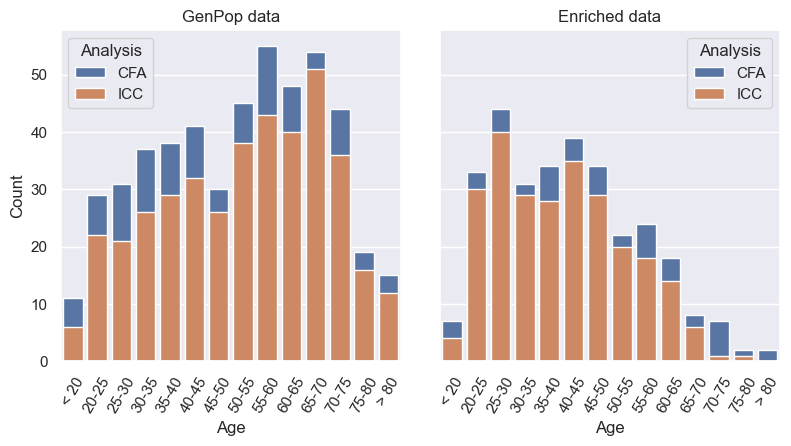

In [63]:
# Plot

# neat labels
labels = ['< 20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60-65', '65-70', '70-75', '75-80', '> 80']

# plot - version 1 - separately for cfa and icc
fig, axes = plt.subplots(1, 2, sharey=True)
#fig.suptitle('Data split by GenPop vs Enriched')
fig.tight_layout()
sns.set(font_scale=0.9)
sns.set_theme(rc={'figure.figsize':(8, 4)})

ax = sns.barplot(data=age_genpop_cfa, x='binned_ages', y='count', label = 'CFA', ax = axes[0])
ax = sns.barplot(data=age_genpop_icc, x='binned_ages', y='count', label = 'ICC', ax = axes[0])
ax.set(xlabel='Age', ylabel='Count')
ax.legend(title='Analysis') # Add the legend
ax.set_title("GenPop data")
ax.set_xticklabels(labels, rotation=60)

ax = sns.barplot(data=age_enriched_cfa, x='binned_ages', y='count', label = 'CFA', ax = axes[1])
ax = sns.barplot(data=age_enriched_icc, x='binned_ages', y='count', label = 'ICC', ax = axes[1])
ax.set(xlabel='Age', ylabel='Count')
ax.legend(title='Analysis') # Add the legend
ax.set_title("Enriched data")
ax.set_xticklabels(labels, rotation=60)

plt.show()

### --> do the same for validation

In [76]:
bins = [0, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, np.inf]
labels = ['< 20', '20-25', '25-30', '30-35', '35-40', '40-45', '45-50', '50-55', '55-60', '60-65', '65-70', '70-75', '75-80', '> 80']
data_val_full['binned_ages'] = pd.cut(data_val_full['age'], bins=bins, labels=labels, right=False) # right=False makes bins left-inclusive
# count bins
valage_data_binned = data_val_full.binned_ages.value_counts().sort_index()
valage_data_binned = valage_data_binned.reset_index()

/var/folders/d8/s1szglf95wl4_7_f5jkmn561n3477x/T/ipykernel_76944/1302997288.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=60)
/var/folders/d8/s1szglf95wl4_7_f5jkmn561n3477x/T/ipykernel_76944/1302997288.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=60)


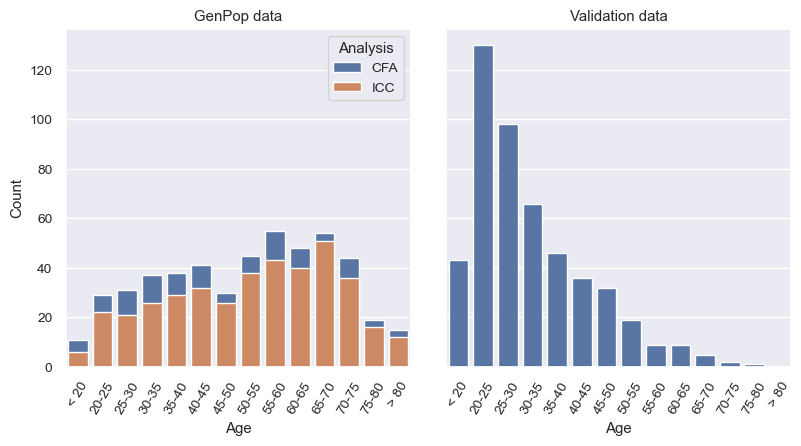

In [81]:
# plot - version 1 - separately for cfa and icc
fig, axes = plt.subplots(1, 2, sharey=True)
#fig.suptitle('Data split by GenPop vs Enriched')
fig.tight_layout()
sns.set(font_scale=0.9)

ax = sns.barplot(data=age_genpop_cfa, x='binned_ages', y='count', label = 'CFA', ax = axes[0])
ax = sns.barplot(data=age_genpop_icc, x='binned_ages', y='count', label = 'ICC', ax = axes[0])
ax.set(xlabel='Age', ylabel='Count')
ax.legend(title='Analysis') # Add the legend
ax.set_title("GenPop data")
ax.set_xticklabels(labels, rotation=60)

ax = sns.barplot(data=valage_data_binned, x='binned_ages', y='count')
ax.set(xlabel='Age', ylabel='Count')
ax.set_title("Validation data")
ax.set_xticklabels(labels, rotation=60)

plt.show()

# REMOVE BELOW

In [13]:
# check i can do icc

In [12]:
data_genpop_gridall

,hitop157,hitop81,hitop34,hitop54,hitop243,hitop182,hitop69,hitop89,hitop50,hitop129,hitop265,hitop124,hitop231,hitop93,hitop67,hitop245,hitop281,hitop141,hitop40,hitop204,hitop21,hitop236,hitop280,hitop84,hitop120,hitop77,hitop92,hitop258,hitop39,hitop254,hitop215,hitop95,hitop106,hitop283,hitop16,hitop20,hitop189,hitop1,hitop136,hitop246,hitop248,hitop257,hitop114,hitop117,hitop250,hitop200,hitop160,hitop23,hitop165,hitop244,hitop9,hitop142,hitop230,hitop149,hitop247,hitop99,hitop66,hitop240,hitop222,hitop90,hitop113,hitop278,hitop203,hitop159,hitop123,hitop275,hitop268,hitop225,hitop143,hitop151,hitop181,hitop211,hitop17,hitop126,hitop5,hitop261,hitop220,hitop15,hitop72,hitop140,hitop109,hitop197,hitop104,hitop157_recontact,hitop81_recontact,hitop34_recontact,hitop54_recontact,hitop243_recontact,hitop182_recontact,hitop69_recontact,hitop89_recontact,hitop50_recontact,hitop129_recontact,hitop265_recontact,hitop124_recontact,hitop231_recontact,hitop93_recontact,hitop67_recontact,hitop245_recontact,hitop281_recontact,hitop141_recontact,hitop40_recontact,hitop204_recontact,hitop21_recontact,hitop236_recontact,hitop280_recontact,hitop84_recontact,hitop120_recontact,hitop77_recontact,hitop92_recontact,hitop258_recontact,hitop39_recontact,hitop254_recontact,hitop215_recontact,hitop95_recontact,hitop106_recontact,hitop283_recontact,hitop16_recontact,hitop20_recontact,hitop189_recontact,hitop1_recontact,hitop136_recontact,hitop246_recontact,hitop248_recontact,hitop257_recontact,hitop114_recontact,hitop117_recontact,hitop250_recontact,hitop200_recontact,hitop160_recontact,hitop23_recontact,hitop165_recontact,hitop244_recontact,hitop9_recontact,hitop142_recontact,hitop230_recontact,hitop149_recontact,hitop247_recontact,hitop99_recontact,hitop66_recontact,hitop240_recontact,hitop222_recontact,hitop90_recontact,hitop113_recontact,hitop278_recontact,hitop203_recontact,hitop159_recontact,hitop123_recontact,hitop275_recontact,hitop268_recontact,hitop225_recontact,hitop143_recontact,hitop151_recontact,hitop181_recontact,hitop211_recontact,hitop17_recontact,hitop126_recontact,hitop5_recontact,hitop261_recontact,hitop220_recontact,hitop15_recontact,hitop72_recontact,hitop140_recontact,hitop109_recontact,hitop197_recontact,hitop104_recontact,hitop_anhedonic_depression,hitop_anhedonic_depression_recontact,hitop_anxious_worry,hitop_anxious_worry_recontact,hitop_appetite_gain,hitop_appetite_gain_recontact,hitop_appetite_loss,hitop_appetite_loss_recontact,hitop_cognitive_problems,hitop_cognitive_problems_recontact,hitop_hyposomnia,hitop_hyposomnia_recontact,hitop_indecisiveness,hitop_indecisiveness_recontact,hitop_insomnia,hitop_insomnia_recontact,hitop_panic,hitop_panic_recontact,hitop_separation_insecurity,hitop_separation_insecurity_recontact,hitop_shame_guilt,hitop_shame_guilt_recontact,hitop_situational_phobia,hitop_situational_phobia_recontact,hitop_social_anxiety,hitop_social_anxiety_recontact,hitop_well_being,hitop_well_being_recontact,hitop_sum,hitop_sum_recontact,whichdata
0,2,2,3,4,3,2,2,2,1,2,3,1,1,1,2,4,4,3,1,2,2,2,1,1,1,1,1,1,1,1,1,2,3,1,1,2,4,2,2,1,2,1,1,2,4,3,1,4,1,4,4,2,1,4,1,1,1,2,1,2,1,1,4,2,1,2,1,1,2,2,1,1,1,1,1,2,1,1,1,2,1,1,1,3,1,2,4,3,1,2,2,2,2,2,1,1,1,1,4,4,3,1,1,2,2,1,1,1,2,1,1,1,1,1,1,4,1,1,2,2,1,1,1,2,1,1,1,1,3,1,4,1,4,4,2,1,4,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,3,1,1,1,1,1,1,1,12,13,18,13,9,8,3,3,10,6,5,5,6,4,5,6,6,6,12,10,6,4,5,5,15,12,38,36,112,95,genpop
1,2,1,4,4,1,3,1,3,1,2,4,3,1,2,3,4,4,4,2,4,2,3,2,1,2,4,2,2,1,2,1,2,4,1,3,4,2,3,1,2,2,4,2,2,1,4,3,4,4,4,4,2,2,4,4,2,3,2,4,2,2,2,1,3,1,2,1,2,2,2,2,4,2,3,2,2,2,3,1,2,2,1,3,2,1,3,4,1,2,1,2,1,3,4,2,2,2,1,4,4,4,1,3,3,2,2,1,1,4,2,2,2,4,1,2,4,3,4,2,3,2,1,2,2,2,1,2,2,2,3,4,4,4,4,2,2,4,4,3,2,2,4,2,1,1,1,2,1,2,2,2,1,1,2,2,2,2,2,3,1,2,1,1,2,1,2,20,20,20,16,9,8,5,7,10,8,10,11,6,7,8,12,18,11,11,8,7,4,15,15,27,23,37,36,166,150,genpop
3,2,1,1,3,2,1,1,1,1,1,1,1,1,1,1,3,1,2,1,1,1,1,1,1,2,1,1,1,1,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,3,4,4,3,2,1,3,2,1,1,1,1,1,1,1,1,1,1,1,4,1,1,1,1,1,

In [ ]:
# Load genpop data
print('\n Process GP data')
data_genpop_full_gridall, data_genpop_gridall, data_genpop_norecontact_gridall = load_data('genpop', doing_checks = True, doing_remove_checks='grid')

# Load enriched data
print('\n Process EN data')
data_enriched_full_gridall, data_enriched_gridall, data_enriched_norecontact_gridall = load_data('enriched', doing_checks = True, doing_remove_checks='grid')


In [22]:
# check we can do descriptive

# data for icc - data_genpop_recontactanalysis, data_enriched_recontactanalysis
# but it is from preprocessing data_genpop_full, data_genpop
# data for cfa - mydata_val_genpop_firstvisitonly, mydata_val_enriched_firstvisitonly, data_genpop_enriched_firstvisitonly

data_genpop_full.sex.value_counts()


sex
2    266
1    231
Name: count, dtype: int64

In [24]:
data_genpop_firstvisitonly.sex.value_counts()

AttributeError: 'DataFrame' object has no attribute 'sex'